# Dist2 (脱エタン塔 partial cond) 入出力検証

HYSYS との比較用。設計条件 (P, N, R, q, feed) を上で編集 → 全セル実行で詳細結果を確認できる。

| セクション | 内容 |
|---|---|
| §1 入力条件 | フィード組成・流量、塔設計値 |
| §2 simulate_column2 実行 | rigorous フルパイプライン |
| §3 入出力ストリーム | フィード, 塔頂, 塔底 を kmol/h と mol% で並べる |
| §4 マスバランス検算 | 成分別に feed = top + bot を確認 |
| §5 T プロファイル | 全段の T (°C) + フィード段 |
| §6 K, x, y プロファイル | 塔頂・フィード段・塔底の VLE 詳細 |
| §7 装置詳細 | CAPEX, Q, A, 冷媒, T 範囲 |
| §8 HYSYS 比較表 | HYSYS 報告値を貼り付けて並べる |
| §9 プロット | T, x, y, K の塔内変化 |

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# 循環 import 回避: flowsheet を先に
import flowsheet  # noqa
from src.distillation_core import ColumnTunables, DistDesignVars
from src.distillation_rigorous import wang_henke_solve
from stream.stream import ProcessStream
from units.separators.column2.column2 import simulate_column2

warnings.filterwarnings('default', category=UserWarning)

_COMP_NAMES = {'A': 'C3H8', 'B': 'C3H6', 'C': 'H2', 'D': 'C2H4', 'E': 'CH4', 'F': 'C2H6'}
_COMPS = ['A', 'B', 'C', 'D', 'E', 'F']
print('OK imports')

OK imports


---
## §1 入力条件 (ここを編集)

下のセルでフィード組成・設計値を書き換える。

In [2]:
# === フィード組成 [kmol/h] ===
# catofin best (trial #201, outputs/main_20260605_170938) の Dist2 入口 (Desuper 後)
F_feed = {
    'A': 2144.0,   # C3H8
    'B': 3305.3,   # C3H6
    'C':  897.0,   # H2
    'D':   12.4,   # C2H4
    'E':  291.7,   # CH4
    'F':  279.3,   # C2H6
}
T_feed_C = 50.0       # フィード温度 [°C]
q_feed   = 0.0        # フィード状態 (0=飽和気, 1=飽和液) — column2.py 既定値

# === 塔設計値 ===
P_col_bar    = 7.881  # 塔操作圧力 [bar] (col2_p = 788.1 kPa)
N_stages     = 61     # 理論段数
reflux_ratio = 11.801 # R = L/D

# === D 直接指定 (HYSYS の Distillate Rate spec 相当) ===
# None: 従来通り FUG (recovery 99/99) が D を計算 (= 1648 など)
# float: rigorous で D_total をその値に強制 (HYSYS 比較用)
# 例: HYSYS の D = 1500 なら D_override_kmolh = 1500.0
D_override_kmolh = None

# === ソルバ ===
solver = 'rigorous'    # 'fug' | 'rigorous'

# === HYSYS 報告値 (比較用、ある場合のみ) ===
HYSYS = {
    'D_kmolh':      None,    # 塔頂 vapor distillate 流量 [kmol/h]
    'B_kmolh':      None,    # 塔底 liquid 流量 [kmol/h]
    'T_top_C':      None,    # 塔頂温度 [°C]
    'T_bot_C':      None,    # 塔底温度 [°C]
    'y_top':        None,    # 塔頂組成 dict, 例 {'B': 0.01, 'C': 0.7, ...}
    'x_bot':        None,    # 塔底組成 dict
    'C3H6_leak_pct': 1.0,    # 塔頂 C3H6 漏れ率 [%]
}

# 確認表示
F_total = sum(F_feed.values())
print('=== 入力サマリ ===')
print(f'feed total = {F_total:.1f} kmol/h')
print(f'feed mole%:')
for c in _COMPS:
    pct = 100 * F_feed[c] / F_total
    print(f'  {c}({_COMP_NAMES[c]:5s}): {F_feed[c]:9.1f} kmol/h ({pct:5.2f}%)')
print(f'feed T = {T_feed_C} °C, q = {q_feed}')
print(f'column: P = {P_col_bar} bar, N = {N_stages}, R = {reflux_ratio}, solver = {solver}')
if D_override_kmolh is not None:
    print(f'D_override = {D_override_kmolh} kmol/h (recovery spec を上書き)')
else:
    print('D_override = None (FUG が recovery spec から D を計算)')

=== 入力サマリ ===
feed total = 6929.7 kmol/h
feed mole%:
  A(C3H8 ):    2144.0 kmol/h (30.94%)
  B(C3H6 ):    3305.3 kmol/h (47.70%)
  C(H2   ):     897.0 kmol/h (12.94%)
  D(C2H4 ):      12.4 kmol/h ( 0.18%)
  E(CH4  ):     291.7 kmol/h ( 4.21%)
  F(C2H6 ):     279.3 kmol/h ( 4.03%)
feed T = 50.0 °C, q = 0.0
column: P = 7.881 bar, N = 61, R = 11.801, solver = rigorous
D_override = None (FUG が recovery spec から D を計算)


---
## §2 simulate_column2 実行

In [3]:
feed_stream = ProcessStream(F_in=F_feed, T_in=T_feed_C + 273.15, P_in=P_col_bar * 1e5)
tunables = ColumnTunables(
    P_col=P_col_bar * 1e5,
    N_stages=N_stages,
    N_feed=1,                          # Kirkbride 自動採用 (rigorous)
    reflux_ratio=reflux_ratio,
    solver_method=solver,
    D_override=D_override_kmolh,       # None or 直接指定値
)

# warning も拾う
with warnings.catch_warnings(record=True) as w_list:
    warnings.simplefilter('always')
    if q_feed != 0.0:
        print(f'[NOTE] q_feed={q_feed} だが column2.py は q=0 固定。下記は q=0 の結果')
    res = simulate_column2(feed_stream, tunables=tunables)

captured_warnings = [str(w.message) for w in w_list]
print(f'実行 OK  (warnings: {len(captured_warnings)})')
for msg in captured_warnings:
    print(f'  ! {msg[:160]}')

実行 OK  (warnings: 3)
  ! partial condenser: comp 'B' が F_top に 118.31 kmol/h (3.58% of feed) 漏出。 閾値 1.0% 超 → 物理値を残す。 設計 (P_col=7.9bar, R=11.80, N=61) の見直しを検討。
  ! partial condenser: comp 'A' が F_top に 21.44 kmol/h (1.00% of feed) 漏出。 閾値 1.0% 超 → 物理値を残す。 設計 (P_col=7.9bar, R=11.80, N=61) の見直しを検討。
  ! rigorous partial cond: comp 'B' が F_top に 135.32 kmol/h (4.09% of feed) 漏出。 閾値 1.0% 超 → 物理値を残す。 設計 (P_col=7.9bar, R=11.80, N=61) の見直しを検討。


---
## §3 入出力ストリーム

In [4]:
F_top = res.top.F_in
F_bot = res.bottom.F_in
F_top_total = sum(F_top.values())
F_bot_total = sum(F_bot.values())

rows = []
for c in _COMPS:
    f_in  = F_feed.get(c, 0.0)
    f_top = F_top.get(c, 0.0)
    f_bot = F_bot.get(c, 0.0)
    rows.append({
        '成分':           f'{c}({_COMP_NAMES[c]})',
        'feed[kmol/h]':   round(f_in, 4),
        'feed[mol%]':     round(100 * f_in / F_total, 4) if F_total > 0 else 0,
        'top[kmol/h]':    round(f_top, 4),
        'top[mol%]':      round(100 * f_top / F_top_total, 4) if F_top_total > 0 else 0,
        'bot[kmol/h]':    round(f_bot, 4),
        'bot[mol%]':      round(100 * f_bot / F_bot_total, 4) if F_bot_total > 0 else 0,
        'to_top[%]':      round(100 * f_top / f_in, 4) if f_in > 0 else None,
        'to_bot[%]':      round(100 * f_bot / f_in, 4) if f_in > 0 else None,
    })
df_streams = pd.DataFrame(rows)
print(df_streams.to_string(index=False))
print()
print(f'total: feed = {F_total:.2f}, top = {F_top_total:.2f}, bot = {F_bot_total:.2f}')
print(f'check: top + bot = {F_top_total + F_bot_total:.2f} (feed との差 {F_top_total + F_bot_total - F_total:+.4e})')
print()
print(f'★ C3H6 漏れ率 (top): {100*F_top.get("B",0)/F_feed["B"]:.4f}%')
print(f'★ C3H8 漏れ率 (top): {100*F_top.get("A",0)/F_feed["A"]:.4f}%')
print(f'★ C2H6 塔頂回収率: {100*F_top.get("F",0)/F_feed["F"]:.4f}% (LK)')

     成分  feed[kmol/h]  feed[mol%]  top[kmol/h]  top[mol%]  bot[kmol/h]  bot[mol%]  to_top[%]  to_bot[%]
A(C3H8)        2144.0     30.9393       0.0000     0.0000    2144.0964    40.3466     0.0000   100.0045
B(C3H6)        3305.3     47.6976     135.3249     8.3766    3170.0982    59.6534     4.0942    95.9095
  C(H2)         897.0     12.9443     896.8670    55.5162       0.0000     0.0000    99.9852     0.0000
D(C2H4)          12.4      0.1789      12.3982     0.7674       0.0000     0.0000    99.9852     0.0000
 E(CH4)         291.7      4.2094     291.6568    18.0536       0.0000     0.0000    99.9852     0.0000
F(C2H6)         279.3      4.0305     279.2586    17.2861       0.0000     0.0000    99.9852     0.0000

total: feed = 6929.70, top = 1615.51, bot = 5314.19
check: top + bot = 6929.70 (feed との差 +9.0949e-13)

★ C3H6 漏れ率 (top): 4.0942%
★ C3H8 漏れ率 (top): 0.0000%
★ C2H6 塔頂回収率: 99.9852% (LK)


---
## §4 マスバランス検算

In [5]:
print('成分別マスバランス: feed - top - bot')
print(f'  {"成分":>8} | {"feed":>10} | {"top":>10} | {"bot":>10} | {"残差":>12} | {"残差/feed%":>11}')
max_rel_err = 0.0
for c in _COMPS:
    f_in  = F_feed.get(c, 0.0)
    f_top = F_top.get(c, 0.0)
    f_bot = F_bot.get(c, 0.0)
    resid = f_in - f_top - f_bot
    rel = 100 * abs(resid) / f_in if f_in > 0 else 0
    max_rel_err = max(max_rel_err, rel)
    flag = '✓' if rel < 0.1 else ('⚠️' if rel < 1.0 else '✗')
    print(f'  {c}({_COMP_NAMES[c]:5s}) | {f_in:10.4f} | {f_top:10.4f} | {f_bot:10.4f} | {resid:+12.4e} | {rel:10.4f}% {flag}')
print(f'\n  最大相対残差: {max_rel_err:.4f}% → {"OK" if max_rel_err < 1.0 else "NG"}')

成分別マスバランス: feed - top - bot
        成分 |       feed |        top |        bot |           残差 |    残差/feed%
  A(C3H8 ) |  2144.0000 |     0.0000 |  2144.0964 |  -9.6449e-02 |     0.0045% ✓
  B(C3H6 ) |  3305.3000 |   135.3249 |  3170.0982 |  -1.2306e-01 |     0.0037% ✓
  C(H2   ) |   897.0000 |   896.8670 |     0.0000 |  +1.3302e-01 |     0.0148% ✓
  D(C2H4 ) |    12.4000 |    12.3982 |     0.0000 |  +1.8383e-03 |     0.0148% ✓
  E(CH4  ) |   291.7000 |   291.6568 |     0.0000 |  +4.3247e-02 |     0.0148% ✓
  F(C2H6 ) |   279.3000 |   279.2586 |     0.0000 |  +4.1408e-02 |     0.0148% ✓

  最大相対残差: 0.0148% → OK


---
## §5 T プロファイル

In [6]:
# rigorous の場合 wang_henke を直呼びして詳細プロファイルを取得
fug_tun = ColumnTunables(
    P_col=P_col_bar * 1e5, N_stages=N_stages,
    N_feed=1, reflux_ratio=reflux_ratio,
    solver_method='fug',
)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    fug_res = simulate_column2(feed_stream, tunables=fug_tun)

# D: D_override があれば直接使用、なければ FUG から
if D_override_kmolh is not None:
    D_use = D_override_kmolh
    print(f'D = {D_use:.2f} kmol/h (D_override 指定)')
else:
    D_use = sum(fug_res.top.F_in.values())
    print(f'D = {D_use:.2f} kmol/h (FUG 計算)')

N_feed_kirk = max(1, min(fug_res.equipment.N_feed_kirkbride, N_stages))

rig = wang_henke_solve(
    feed_F=F_feed, comps=_COMPS,
    P_col=P_col_bar * 1e5, N_stages=N_stages,
    N_feed=N_feed_kirk,
    reflux_ratio=reflux_ratio, D_total=D_use,
    q_feed=q_feed, partial_condenser=True,
    T_top_init_K=fug_res.equipment.T_top,
    T_bot_init_K=fug_res.equipment.T_bot,
    max_iter=500,
)
print(f'rigorous: converged={rig.converged}, iter={rig.n_iter}')
print(f'  mesh_residual_max = {rig.mesh_residual_max:.3e}')
print(f'  component_balance_max = {rig.component_balance_max:.3e}')
print(f'  T_top = {rig.T_profile_K[0]-273.15:.2f} °C')
print(f'  T_bot = {rig.T_profile_K[-1]-273.15:.2f} °C')
print(f'  N_feed = {N_feed_kirk} (Kirkbride 推奨)')
print()

# 段別 T を表で
rows = []
for j in range(1, N_stages + 1):
    label = ''
    if j == 1: label = '← 塔頂 (partial cond)'
    elif j == N_feed_kirk: label = f'← フィード段'
    elif j == N_stages: label = '← 塔底 (reboiler)'
    rows.append({'stage': j, 'T[°C]': round(rig.T_profile_K[j-1] - 273.15, 2), 'note': label})
df_T = pd.DataFrame(rows)
# 表が長いので「特定段 + 10 段おき」だけ表示
show_idx = sorted(set([0, 1, N_feed_kirk-1, N_stages-1] + list(range(0, N_stages, 5))))
df_T_show = df_T.iloc[show_idx]
print(df_T_show.to_string(index=False))

D = 1617.35 kmol/h (FUG 計算)


rigorous: converged=True, iter=60
  mesh_residual_max = 2.721e-04
  component_balance_max = 1.483e-04
  T_top = -55.39 °C
  T_bot = 13.23 °C
  N_feed = 21 (Kirkbride 推奨)

 stage  T[°C]                note
     1 -55.39 ← 塔頂 (partial cond)
     2  -2.49                    
     6   7.35                    
    11   7.77                    
    16   8.35                    
    21   9.35             ← フィード段
    26  12.57                    
    31  12.58                    
    36  12.58                    
    41  12.58                    
    46  12.58                    
    51  12.59                    
    56  12.67                    
    61  13.23     ← 塔底 (reboiler)


---
## §6 K, x, y プロファイル (重要段)

In [7]:
def show_stage(j_one_indexed, label):
    j = j_one_indexed - 1
    print(f'\n--- stage {j_one_indexed} ({label}) ---')
    print(f'  T = {rig.T_profile_K[j]-273.15:.2f} °C')
    print(f'  {"成分":>8} | {"x_j":>12} | {"y_j":>12} | {"K_j":>12} | {"K×x":>12}')
    sum_Kx = 0.0
    for c in _COMPS:
        x_v = rig.x_profile[j].get(c, 0.0)
        y_v = rig.y_profile[j].get(c, 0.0)
        K_v = rig.K_profile[j].get(c, 0.0)
        Kx = K_v * x_v
        sum_Kx += Kx
        print(f'  {c}({_COMP_NAMES[c]:5s}) | {x_v:12.5e} | {y_v:12.5e} | {K_v:12.4f} | {Kx:12.5e}')
    print(f'  sum(K×x) = {sum_Kx:.6f}  (理想 = 1.0 で泡点条件成立、ズレは subcool/superheat)')

show_stage(1, '塔頂 partial cond')
show_stage(N_feed_kirk, 'フィード段')
show_stage(N_stages, '塔底 reboiler')


--- stage 1 (塔頂 partial cond) ---
  T = -55.39 °C
        成分 |          x_j |          y_j |          K_j |          K×x
  A(C3H8 ) |  1.16075e-02 |  1.13899e-03 |       0.0981 |  1.13924e-03
  B(C3H6 ) |  6.78646e-01 |  8.36709e-02 |       0.1233 |  8.36890e-02
  C(H2   ) |  4.82863e-03 |  5.54530e-01 |     114.8669 |  5.54650e-01
  D(C2H4 ) |  6.90961e-03 |  7.66574e-03 |       1.1097 |  7.66740e-03
  E(CH4  ) |  2.19328e-02 |  1.80330e-01 |       8.2237 |  1.80369e-01
  F(C2H6 ) |  2.76075e-01 |  1.72665e-01 |       0.6256 |  1.72702e-01
  sum(K×x) = 1.000217  (理想 = 1.0 で泡点条件成立、ズレは subcool/superheat)

--- stage 21 (フィード段) ---
  T = 9.35 °C
        成分 |          x_j |          y_j |          K_j |          K×x
  A(C3H8 ) |  3.10975e-01 |  2.56335e-01 |       0.8243 |  2.56335e-01
  B(C3H6 ) |  6.80578e-01 |  6.64344e-01 |       0.9761 |  6.64345e-01
  C(H2   ) |  5.31456e-04 |  4.38156e-02 |      82.4446 |  4.38157e-02
  D(C2H4 ) |  1.77386e-04 |  7.62990e-04 |       4.3013 |  7.629

---
## §7 装置詳細

In [8]:
eq = res.equipment
print('=== 塔本体 ===')
print(f'  D_col = {eq.D_col:.3f} m')
print(f'  H_col = {eq.H_col:.3f} m')
print(f'  V_col = {eq.V_col:.3f} m³')
print(f'  N_min  = {eq.N_min:.3f}')
print(f'  R_min  = {eq.R_min:.3f}')
print(f'  R/R_min = {reflux_ratio/eq.R_min:.3f}')
print(f'  N/N_min = {N_stages/eq.N_min:.3f}')
print(f'  feasible = {eq.feasible}')
print()
print('=== 熱量・装置 ===')
print(f'  T_top = {eq.T_top-273.15:.2f} °C, T_bot = {eq.T_bot-273.15:.2f} °C')
print(f'  Q_cond = {eq.Q_cond:.1f} kW (放熱), A_cond = {eq.A_cond_m2:.1f} m²')
print(f'    util: {eq.cond_utility_name} ({eq.cond_utility_jpy_per_GJ:.1f} 円/GJ)')
print(f'  Q_reb  = {eq.Q_reb:.1f} kW (吸熱), A_reb  = {eq.A_reb_m2:.1f} m²')
print(f'    util: {eq.reb_utility_name} ({eq.reb_utility_jpy_per_GJ:.1f} 円/GJ)')
print()
print('=== CAPEX [億円] ===')
print(f'  Vessel  = {eq.CAPEX_vessel:.4f}')
print(f'  Trays   = {eq.CAPEX_trays:.4f}')
print(f'  Cond    = {eq.CAPEX_cond:.4f}')
print(f'  Reb     = {eq.CAPEX_reb:.4f}')
print(f'  合計    = {eq.CAPEX:.4f}')
print()
if eq.proxy_penalty_okuyen > 0:
    print(f'⚠ Proxy 罰則 = {eq.proxy_penalty_okuyen:.2f} 億円/年')
    print(f'   理由: {eq.proxy_penalty_reason}')

=== 塔本体 ===
  D_col = 6.895 m
  H_col = 52.200 m
  V_col = 1949.202 m³
  N_min  = 3.263
  R_min  = 3.537
  R/R_min = 3.337
  N/N_min = 18.692
  feasible = True

=== 熱量・装置 ===
  T_top = -55.39 °C, T_bot = 13.23 °C
  Q_cond = 100434.5 kW (放熱), A_cond = 4775.6 m²
    util: エチレン冷媒-75C≒ (4025.9 円/GJ)
  Q_reb  = 71358.5 kW (吸熱), A_reb  = 324.1 m²
    util: LP Steam≒ (1050.0 円/GJ)

=== CAPEX [億円] ===
  Vessel  = 64.1193
  Trays   = 10.9263
  Cond    = 3.2810
  Reb     = 0.4879
  合計    = 78.8145



---
## §8 HYSYS との比較

In [9]:
rows = []
def add(label, sim, hys, unit=''):
    diff = None
    diff_pct = None
    if sim is not None and hys is not None:
        try:
            diff = float(sim) - float(hys)
            diff_pct = 100 * diff / float(hys) if float(hys) != 0 else None
        except Exception:
            pass
    rows.append({
        '項目': label,
        '当方 sim': sim if sim is not None else '—',
        'HYSYS': hys if hys is not None else '—',
        '差 (sim-HYSYS)': f'{diff:+.4f}' if diff is not None else '—',
        '差 [%]': f'{diff_pct:+.2f}' if diff_pct is not None else '—',
        '単位': unit,
    })

add('D (塔頂流量)', round(F_top_total, 2), HYSYS.get('D_kmolh'), 'kmol/h')
add('B (塔底流量)', round(F_bot_total, 2), HYSYS.get('B_kmolh'), 'kmol/h')
add('T_top',       round(eq.T_top - 273.15, 2), HYSYS.get('T_top_C'), '°C')
add('T_bot',       round(eq.T_bot - 273.15, 2), HYSYS.get('T_bot_C'), '°C')
add('C3H6 漏れ率', round(100*F_top.get('B',0)/F_feed['B'], 4), HYSYS.get('C3H6_leak_pct'), '%')

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
print()
if HYSYS.get('y_top'):
    print('y_top 組成比較:')
    print(f'  {"成分":>8} | {"sim mol%":>10} | {"HYSYS mol%":>11} | {"差":>8}')
    for c in _COMPS:
        sim_pct = 100 * F_top.get(c, 0) / F_top_total if F_top_total > 0 else 0
        hys_v = HYSYS['y_top'].get(c)
        if hys_v is not None:
            hys_pct = 100 * hys_v
            print(f'  {c}({_COMP_NAMES[c]:5s}) | {sim_pct:10.4f} | {hys_pct:11.4f} | {sim_pct - hys_pct:+8.4f}')

      項目    当方 sim HYSYS 差 (sim-HYSYS)   差 [%]     単位
D (塔頂流量) 1615.5100     —             —       — kmol/h
B (塔底流量) 5314.1900     —             —       — kmol/h
   T_top  -55.3900     —             —       —     °C
   T_bot   13.2300     —             —       —     °C
C3H6 漏れ率    4.0942   1.0       +3.0942 +309.42      %



---
## §9 プロット (塔内変化)

C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 22612 (\N{CJK UNIFIED IDEOGRAPH-5854}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 38914 (\N{CJK UNIFIED IDEOGRAPH-9802}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarni

C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\4290095196.py:37: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\

Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28082 (\N{CJK UNIFIED IDEOGRAPH-6DB2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  fig.c

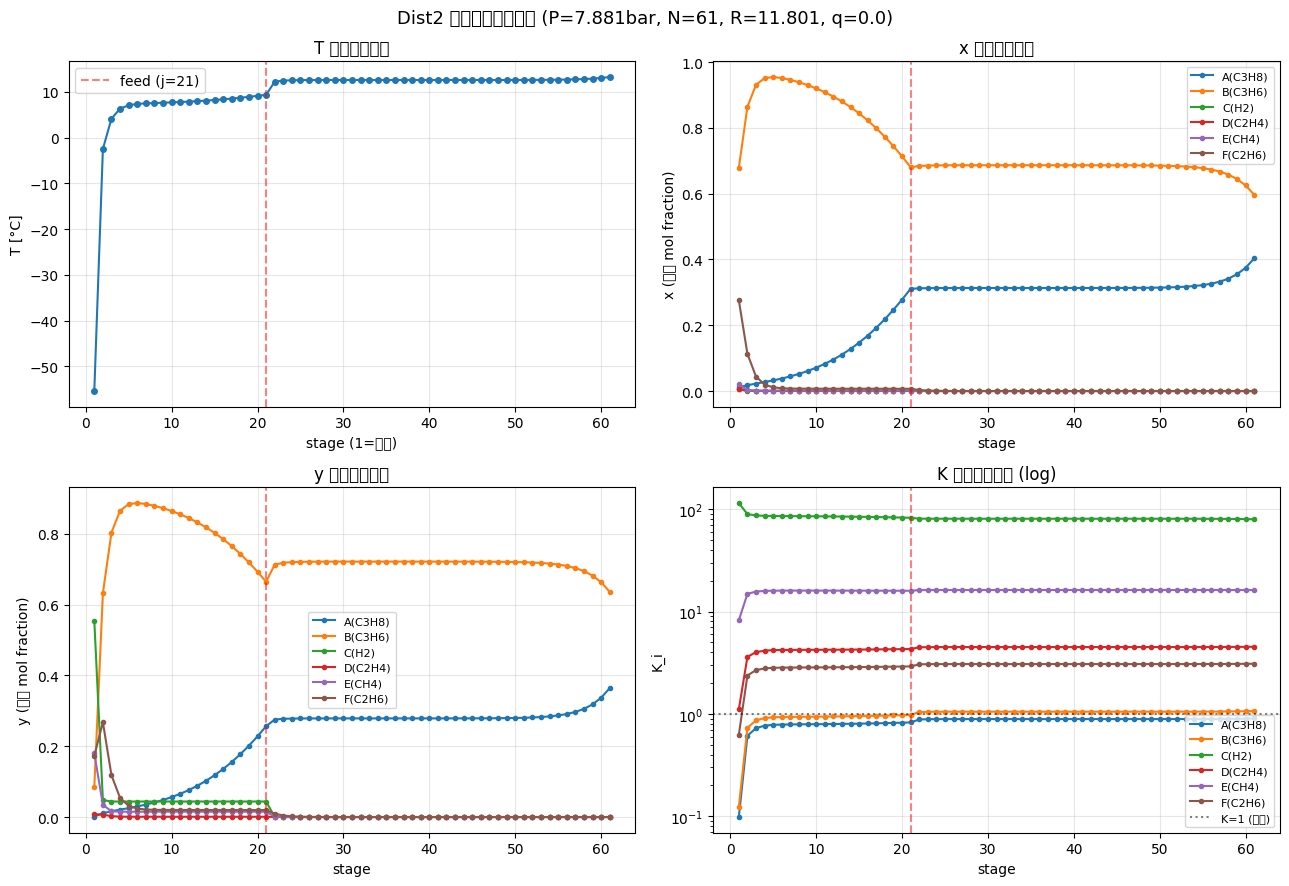

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Dist2 内部プロファイル (P={P_col_bar}bar, N={N_stages}, R={reflux_ratio}, q={q_feed})', fontsize=13)
stages = np.arange(1, N_stages + 1)
T_arr = np.array([rig.T_profile_K[j-1] - 273.15 for j in stages])

ax = axes[0, 0]
ax.plot(stages, T_arr, 'o-', markersize=4)
ax.axvline(N_feed_kirk, ls='--', color='red', alpha=0.5, label=f'feed (j={N_feed_kirk})')
ax.set_xlabel('stage (1=塔頂)'); ax.set_ylabel('T [°C]')
ax.set_title('T プロファイル'); ax.grid(alpha=0.3); ax.legend()

ax = axes[0, 1]
for c in _COMPS:
    x_arr = np.array([rig.x_profile[j-1].get(c, 0) for j in stages])
    ax.plot(stages, x_arr, 'o-', markersize=3, label=f'{c}({_COMP_NAMES[c]})')
ax.axvline(N_feed_kirk, ls='--', color='red', alpha=0.5)
ax.set_xlabel('stage'); ax.set_ylabel('x (液相 mol fraction)')
ax.set_title('x プロファイル'); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1, 0]
for c in _COMPS:
    y_arr = np.array([rig.y_profile[j-1].get(c, 0) for j in stages])
    ax.plot(stages, y_arr, 'o-', markersize=3, label=f'{c}({_COMP_NAMES[c]})')
ax.axvline(N_feed_kirk, ls='--', color='red', alpha=0.5)
ax.set_xlabel('stage'); ax.set_ylabel('y (気相 mol fraction)')
ax.set_title('y プロファイル'); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1, 1]
for c in _COMPS:
    K_arr = np.array([rig.K_profile[j-1].get(c, 0) for j in stages])
    ax.semilogy(stages, K_arr, 'o-', markersize=3, label=f'{c}({_COMP_NAMES[c]})')
ax.axvline(N_feed_kirk, ls='--', color='red', alpha=0.5)
ax.axhline(1.0, ls=':', color='black', alpha=0.5, label='K=1 (境界)')
ax.set_xlabel('stage'); ax.set_ylabel('K_i')
ax.set_title('K プロファイル (log)'); ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## §10 D 感度スキャン (HYSYS との合わせこみ用)

D を 1300-1800 kmol/h で振り、C3H6 漏れ率がどう変わるか。HYSYS の D 値が分かっている場合、当方シミュレータも同 D で 1% に近づくはず。

feed total = 6929.7 kmol/h
F (H2+CH4) 非凝縮 = 1188.7 (物理下限 D)
D @ recovery 99% (非凝縮 + LK 99% + C2H4 99%) = 1477.5



 D[kmol/h]  T_top[°C]  C3H6漏れ[%]  C3H8漏れ[%]  C2H6回収[%]           冷媒
    1477.5     -73.15     0.0000        0.0    98.3409 エチレン冷媒-100C≒
    1502.5     -73.15     0.0000        0.0    99.5707 エチレン冷媒-100C≒
    1527.5     -69.25     1.4060        0.0   100.0028 エチレン冷媒-100C≒
    1552.5     -64.37     2.1532        0.0   100.0006  エチレン冷媒-75C≒
    1577.5     -60.44     2.9014        0.0    99.9953  エチレン冷媒-75C≒
    1602.5     -57.12     3.6492        0.0    99.9897  エチレン冷媒-75C≒
    1627.5     -54.37     4.3829        0.0   100.0153  エチレン冷媒-75C≒
    1652.5     -51.84     5.1288        0.0   100.0122  エチレン冷媒-75C≒
    1677.5     -49.60     5.8791        0.0    99.9983  エチレン冷媒-60C≒
    1702.5     -47.54     6.6216        0.0   100.0014  エチレン冷媒-60C≒
    1727.5     -45.70     7.3677        0.0    99.9956  エチレン冷媒-60C≒



C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\1313615670.py:61: UserWarning: Glyph 28431 (\N{CJK UNIFIED IDEOGRAPH-6F0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\1313615670.py:61: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\1313615670.py:61: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\1313615670.py:61: UserWarning: Glyph 22577 (\N{CJK UNIFIED IDEOGRAPH-5831}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\5koza\AppData\Local\Temp\claude\ipykernel_21056\1313615670.py:61: UserWarning: Glyph 21578 (\N{CJK UNIFIED IDEOGRAPH-544A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users

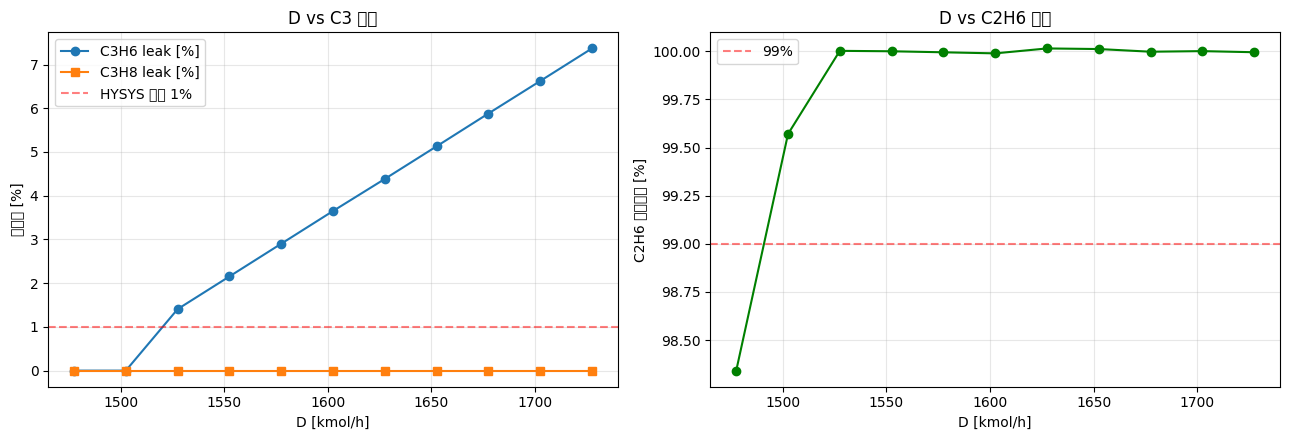

In [11]:
# D を変えて C3H6 漏れがどう変わるかスキャン
# (F_feed の C3H6 + 非凝縮 + LK だけで構成される下限 D を理論計算)
F_noncond = F_feed['C'] + F_feed['E']  # H2 + CH4 (絶対 top)
F_LK_max  = F_feed['F']                # C2H6 全量 (上限ケース)
D_floor   = F_noncond                          # 物理下限 (H2/CH4 だけ)
D_recovery99 = F_noncond + 0.99 * F_LK_max + 0.99 * F_feed['D']  # 非凝縮 + LK 99% + C2H4 99%

print(f'feed total = {F_total:.1f} kmol/h')
print(f'F (H2+CH4) 非凝縮 = {F_noncond:.1f} (物理下限 D)')
print(f'D @ recovery 99% (非凝縮 + LK 99% + C2H4 99%) = {D_recovery99:.1f}')
print()

D_scan = np.linspace(D_recovery99, D_recovery99 + 250, 11)
results = []
for D_try in D_scan:
    tun_try = ColumnTunables(
        P_col=P_col_bar * 1e5, N_stages=N_stages,
        N_feed=1, reflux_ratio=reflux_ratio,
        solver_method='rigorous',
        D_override=float(D_try),
    )
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            r = simulate_column2(feed_stream, tunables=tun_try)
        leak_B = 100 * r.top.F_in.get('B', 0) / F_feed['B']
        leak_A = 100 * r.top.F_in.get('A', 0) / F_feed['A']
        c2h6_top = 100 * r.top.F_in.get('F', 0) / F_feed['F']
        T_top_C = r.equipment.T_top - 273.15
        results.append({
            'D[kmol/h]':   round(float(D_try), 1),
            'T_top[°C]':   round(T_top_C, 2),
            'C3H6漏れ[%]': round(leak_B, 4),
            'C3H8漏れ[%]': round(leak_A, 4),
            'C2H6回収[%]': round(c2h6_top, 4),
            '冷媒':         r.equipment.cond_utility_name,
        })
    except Exception as e:
        results.append({
            'D[kmol/h]': round(float(D_try), 1),
            'T_top[°C]': None, 'C3H6漏れ[%]': None, 'C3H8漏れ[%]': None,
            'C2H6回収[%]': None, '冷媒': f'ERR: {type(e).__name__}',
        })

df_scan = pd.DataFrame(results)
print(df_scan.to_string(index=False))
print()

# プロット
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(df_scan['D[kmol/h]'], df_scan['C3H6漏れ[%]'], 'o-', label='C3H6 leak [%]')
ax[0].plot(df_scan['D[kmol/h]'], df_scan['C3H8漏れ[%]'], 's-', label='C3H8 leak [%]')
ax[0].axhline(1.0, ls='--', color='red', alpha=0.5, label='HYSYS 報告 1%')
ax[0].set_xlabel('D [kmol/h]'); ax[0].set_ylabel('漏れ率 [%]')
ax[0].set_title('D vs C3 漏れ'); ax[0].grid(alpha=0.3); ax[0].legend()

ax[1].plot(df_scan['D[kmol/h]'], df_scan['C2H6回収[%]'], 'o-', color='green')
ax[1].axhline(99.0, ls='--', color='red', alpha=0.5, label='99%')
ax[1].set_xlabel('D [kmol/h]'); ax[1].set_ylabel('C2H6 塔頂回収 [%]')
ax[1].set_title('D vs C2H6 回収'); ax[1].grid(alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()

---
## 使い方メモ

- §1 のセルで `F_feed`, `P_col_bar`, `N_stages`, `reflux_ratio` を編集
- HYSYS の値が分かっている場合は `HYSYS` 辞書に入力 → §8 で並べて表示
- `q_feed` を変えると wang_henke_solve 直呼びの方で反映 (column2.py は q=0 固定なので simulate_column2 結果には影響しない)
- §6 の `sum(K×x)` が 1.0 から大きく外れる段は VLE 未収束 (実装バグや初期化の罠の手がかり)
- §4 マスバランス残差が 1% 超えなら solver 内部不整合の疑い
- §9 のプロットで T が急変する段、K が縮退 (=1 一様) する段は要注意